In [1]:
# Conectarea la Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Instalare librării
!pip -q install -U transformers datasets evaluate rouge_score accelerate sentencepiece

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 26.0 MB/s eta 0:00:00


In [3]:
# Importuri
import os, gc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset, DatasetDict
from torch.utils.data import DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Trainer, TrainingArguments
)
import evaluate

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [4]:
# Calea + încărcare CSV
DATA_DIR = "/content/drive/MyDrive/cnn_dailymail"

train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df   = pd.read_csv(os.path.join(DATA_DIR, "validation.csv"))
test_df  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

TEXT_COL = "article"
SUM_COL  = "highlights"

train_df = train_df[[TEXT_COL, SUM_COL]].dropna()
val_df   = val_df[[TEXT_COL, SUM_COL]].dropna()
test_df  = test_df[[TEXT_COL, SUM_COL]].dropna()

SEED = 42
TRAIN_N = 12000
VAL_N   = 2000
TEST_N  = 2000

train_df = train_df.sample(n=min(TRAIN_N, len(train_df)), random_state=SEED)
val_df   = val_df.sample(n=min(VAL_N, len(val_df)), random_state=SEED)
test_df  = test_df.sample(n=min(TEST_N, len(test_df)), random_state=SEED)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df, preserve_index=False),
    "validation": Dataset.from_pandas(val_df, preserve_index=False),
    "test": Dataset.from_pandas(test_df, preserve_index=False),
})

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights'],
        num_rows: 12000
    })
    validation: Dataset({
        features: ['article', 'highlights'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['article', 'highlights'],
        num_rows: 2000
    })
})


In [5]:
# Funcții tokenizare + evaluare + sumarizare demo
MAX_INPUT  = 384
MAX_TARGET = 96

def preprocess_function(examples, tokenizer):
    model_inputs = tokenizer(
        examples[TEXT_COL],
        max_length=MAX_INPUT,
        truncation=True
    )
    labels = tokenizer(
        text_target=examples[SUM_COL],
        max_length=MAX_TARGET,
        truncation=True
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

rouge = evaluate.load("rouge")

VAL_EVAL_N  = 500
TEST_EVAL_N = 500

def evaluate_rouge_batched(model, tokenizer, hf_dataset, batch_size=2, num_beams=2):
    model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)
    loader = DataLoader(hf_dataset, batch_size=batch_size, shuffle=False, collate_fn=collator)

    preds_text, refs_text = [], []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            generated = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_length=MAX_TARGET,
                num_beams=num_beams
            )

        pred = tokenizer.batch_decode(generated.cpu(), skip_special_tokens=True)

        labels = batch["labels"].cpu().numpy()
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        ref = tokenizer.batch_decode(labels, skip_special_tokens=True)

        preds_text.extend(pred)
        refs_text.extend(ref)

        del input_ids, attention_mask, generated, batch
        torch.cuda.empty_cache()

    result = rouge.compute(predictions=preds_text, references=refs_text, use_stemmer=True)
    return result

def summarize_one_example(model, tokenizer, article_text, num_beams=4):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    model.eval()

    inputs = tokenizer(article_text, return_tensors="pt", truncation=True, max_length=MAX_INPUT)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out_ids = model.generate(**inputs, max_length=MAX_TARGET, num_beams=num_beams)

    return tokenizer.decode(out_ids[0], skip_special_tokens=True)

rouge_demo = evaluate.load("rouge")
def rouge_single(pred, ref):
    s = rouge_demo.compute(predictions=[pred], references=[ref], use_stemmer=True)
    return s

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [9]:
# Funcție train+test (setările tale: 2 epocă, batch=2, grad_acc=16)
def train_test_one_model(model_ckpt, run_name):
    tokenizer = AutoTokenizer.from_pretrained(model_ckpt, use_fast=True)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_ckpt)

    tokenized_train = dataset["train"].map(
        lambda x: preprocess_function(x, tokenizer),
        batched=True,
        remove_columns=dataset["train"].column_names
    )

    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model, padding=True)

    args = TrainingArguments(
        output_dir=f"/content/{run_name}",
        learning_rate=2e-5,
        num_train_epochs=2,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=16,
        fp16=True,
        logging_steps=100,
        save_strategy="no",
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_train,
        data_collator=data_collator
    )
    trainer.train()

    # Testare ROUGE pe subset de test
    tokenized_test = dataset["test"].map(
        lambda x: preprocess_function(x, tokenizer),
        batched=True,
        remove_columns=dataset["test"].column_names
    )
    test_ds = tokenized_test.select(range(min(TEST_EVAL_N, len(tokenized_test))))
    test_scores = evaluate_rouge_batched(model, tokenizer, test_ds, batch_size=2, num_beams=2)

    # Demo: pred vs ref + ROUGE pe exemplu
    sample = dataset["test"][3]
    pred = summarize_one_example(model, tokenizer, sample[TEXT_COL], num_beams=4)
    ref  = sample[SUM_COL]
    demo_scores = rouge_single(pred, ref)

    # curățare
    del trainer, tokenized_train, tokenized_test, data_collator
    torch.cuda.empty_cache()
    gc.collect()

    # întoarcem doar rezultate, nu model (ca să nu ținem RAM)
    return {
        "model": run_name,
        "rouge1": test_scores["rouge1"],
        "rouge2": test_scores["rouge2"],
        "rougeL": test_scores["rougeL"],
        "demo_ref": ref,
        "demo_pred": pred,
        "demo_rouge1": demo_scores["rouge1"],
        "demo_rouge2": demo_scores["rouge2"],
        "demo_rougeL": demo_scores["rougeL"],
        "demo_percent": demo_scores["rougeL"] * 100.0
    }

In [10]:
# Model DistilBART (Train+Test)
res_distilbart = train_test_one_model("sshleifer/distilbart-cnn-12-6", "DistilBART")
res_distilbart

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Step,Training Loss
100,1.962500
200,1.808100
300,1.790600
400,1.743400
500,1.606600
600,1.600100
700,1.607700


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'model': 'DistilBART',
 'rouge1': np.float64(0.4361500887956298),
 'rouge2': np.float64(0.1993149090263304),
 'rougeL': np.float64(0.2930324004877971),
 'demo_ref': "Most of those released were women and children .\nFreed Yazidis sent to capital of Iraq's Kurdish region .",
 'demo_pred': "Most of those released were women and children; the rest were ill or elderly .\nThe freed Yazidis were received by Peshmerga, who sent them to the Kurdish regional capital, Irbil .\nIt wasn't immediately clear what motivated Wednesday's release, an official says .",
 'demo_rouge1': np.float64(0.5245901639344261),
 'demo_rouge2': np.float64(0.30508474576271183),
 'demo_rougeL': np.float64(0.459016393442623),
 'demo_percent': np.float64(45.9016393442623)}

In [11]:
# Model BART-base (Train+Test)
res_bart = train_test_one_model("facebook/bart-base", "BART_base")
res_bart

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Step,Training Loss
100,2.732700
200,2.427600
300,2.383800
400,2.338800
500,2.254700
600,2.252100
700,2.243000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'model': 'BART_base',
 'rouge1': np.float64(0.40031937480146174),
 'rouge2': np.float64(0.1729732498935109),
 'rougeL': np.float64(0.2653754963945778),
 'demo_ref': "Most of those released were women and children .\nFreed Yazidis sent to capital of Iraq's Kurdish region .",
 'demo_pred': 'More than 200 Yazidis released, officials say .\nMost of those released were women and children; the rest were ill or elderly .\nThe Yazidis are of Kurdish descent, and their religion is considered a pre-Islamic sect that draws from Christianity, Judaism and Zoroastrianism .',
 'demo_rouge1': np.float64(0.36065573770491804),
 'demo_rouge2': np.float64(0.23728813559322035),
 'demo_rougeL': np.float64(0.36065573770491804),
 'demo_percent': np.float64(36.0655737704918)}

In [12]:
# Model T5-small (Train+Test)
res_t5 = train_test_one_model("t5-small", "T5_small")
res_t5

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Step,Training Loss
100,2.350300
200,2.235900
300,2.227800
400,2.220600
500,2.191300
600,2.187400
700,2.193100


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'model': 'T5_small',
 'rouge1': np.float64(0.3962214814975104),
 'rouge2': np.float64(0.1740267301845424),
 'rougeL': np.float64(0.27759053645519294),
 'demo_ref': "Most of those released were women and children .\nFreed Yazidis sent to capital of Iraq's Kurdish region .",
 'demo_pred': "ISIS released more than 200 Yazidis, a minority group whose members were killed, captured and displaced. Most of those released were women and children; the rest were ill or elderly. ISIS previously released scores of other Yazidis since attacking the group's towns last year.",
 'demo_rouge1': np.float64(0.3492063492063492),
 'demo_rouge2': np.float64(0.22950819672131148),
 'demo_rougeL': np.float64(0.31746031746031744),
 'demo_percent': np.float64(31.746031746031743)}

In [13]:
# Model PEGASUS-xsum (Train+Test)
res_pegasus = train_test_one_model("google/pegasus-xsum", "PEGASUS_xsum")
res_pegasus

tokenizer_config.json:   0%|          | 0.00/87.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/259 [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Step,Training Loss
100,2.521200
200,2.143900
300,2.087400
400,2.064400
500,2.022200
600,2.011100
700,2.025000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'model': 'PEGASUS_xsum',
 'rouge1': np.float64(0.39567622289644633),
 'rouge2': np.float64(0.17916611308234964),
 'rougeL': np.float64(0.27705324554013644),
 'demo_ref': "Most of those released were women and children .\nFreed Yazidis sent to capital of Iraq's Kurdish region .",
 'demo_pred': "More than 200 Yazidis released . Most of those released were women and children . Most of those released were ill or elderly . The freed Yazidis were received by Peshmerga, who sent them to the Kurdish regional capital, Irbil, said Nuri Osman, an official with Iraq's Kurdistan Regional Government .",
 'demo_rouge1': np.float64(0.5454545454545454),
 'demo_rouge2': np.float64(0.3125),
 'demo_rougeL': np.float64(0.48484848484848486),
 'demo_percent': np.float64(48.484848484848484)}

In [14]:
# Model FLAN-T5-small (Train+Test)
res_flan = train_test_one_model("google/flan-t5-small", "FLAN_T5_small")
res_flan

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Step,Training Loss
100,0.000000
200,0.000000
300,0.000000
400,0.000000
500,0.000000
600,0.000000
700,0.000000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

{'model': 'FLAN_T5_small',
 'rouge1': np.float64(0.344291500986291),
 'rouge2': np.float64(0.14638447437456464),
 'rougeL': np.float64(0.2421035889002864),
 'demo_ref': "Most of those released were women and children .\nFreed Yazidis sent to capital of Iraq's Kurdish region .",
 'demo_pred': 'Kurdish tribal leaders have been able to coordinate the release of more than 200 Yazidis, a minority group whose members were killed, captured and displaced when the Islamist terror organization overtook their towns in northern Iraq last summer.',
 'demo_rouge1': np.float64(0.2857142857142857),
 'demo_rouge2': np.float64(0.0),
 'demo_rougeL': np.float64(0.14285714285714285),
 'demo_percent': np.float64(14.285714285714285)}

,model,test_rouge1,test_rouge2,test_rougeL
0,DistilBART,0.436150,0.199315,0.293032
2,T5_small,0.396221,0.174027,0.277591
3,PEGASUS_xsum,0.395676,0.179166,0.277053
1,BART_base,0.400319,0.172973,0.265375
4,FLAN_T5_small,0.344292,0.146384,0.242104


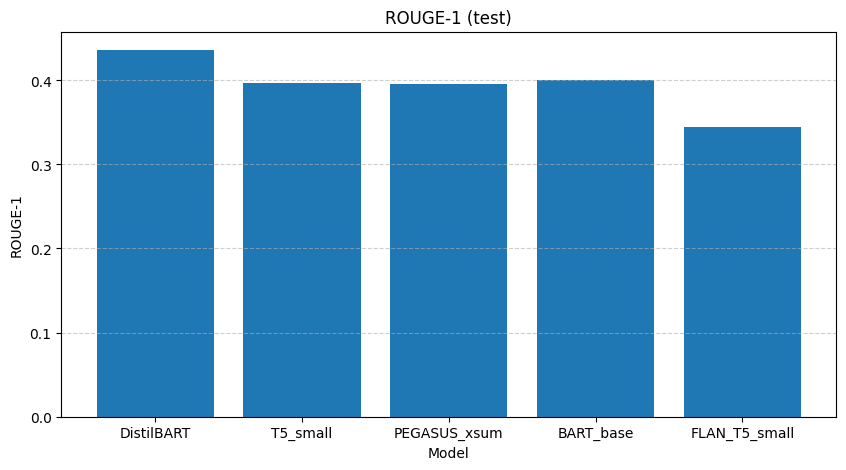

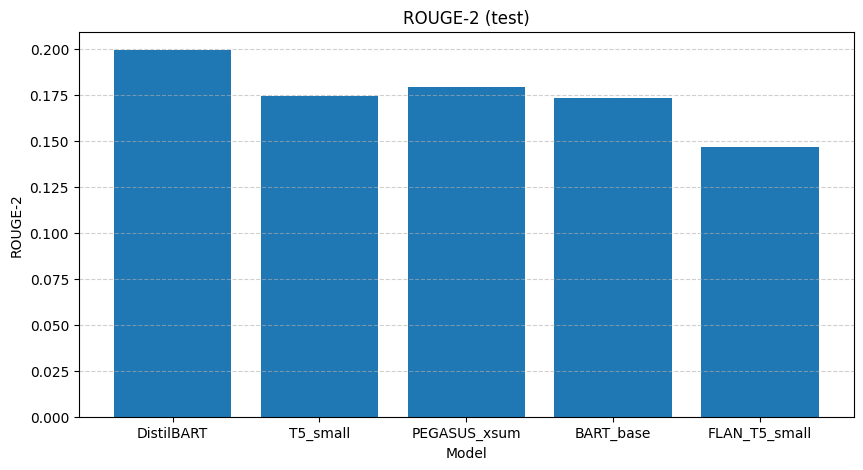

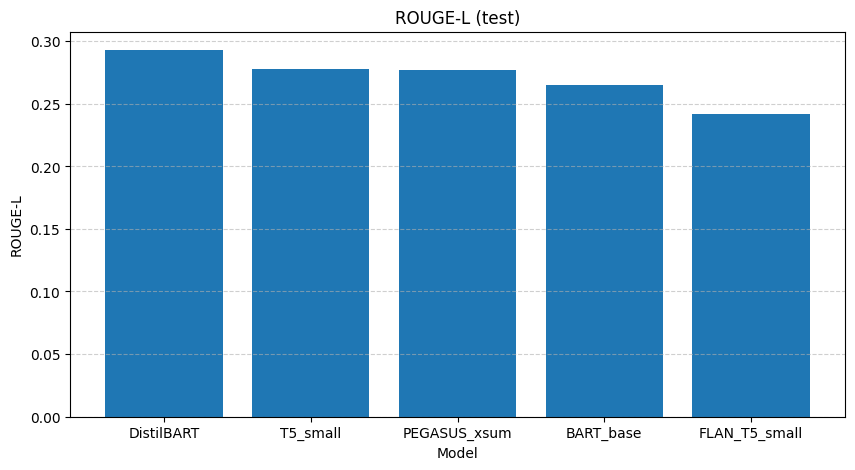

In [15]:
# Tabel rezultate + grafice ROUGE-1/2/L
results = [res_distilbart, res_bart, res_t5, res_pegasus, res_flan]
df_results = pd.DataFrame([{
    "model": r["model"],
    "test_rouge1": r["rouge1"],
    "test_rouge2": r["rouge2"],
    "test_rougeL": r["rougeL"]
} for r in results]).sort_values("test_rougeL", ascending=False)

display(df_results)

# ROUGE-1
plt.figure(figsize=(10,5))
plt.bar(df_results["model"], df_results["test_rouge1"])
plt.title("ROUGE-1 (test)")
plt.xlabel("Model"); plt.ylabel("ROUGE-1")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# ROUGE-2
plt.figure(figsize=(10,5))
plt.bar(df_results["model"], df_results["test_rouge2"])
plt.title("ROUGE-2 (test)")
plt.xlabel("Model"); plt.ylabel("ROUGE-2")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

# ROUGE-L
plt.figure(figsize=(10,5))
plt.bar(df_results["model"], df_results["test_rougeL"])
plt.title("ROUGE-L (test)")
plt.xlabel("Model"); plt.ylabel("ROUGE-L")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

In [16]:
# DEMO final (pred vs ref + “cât de bun” pe exemplu, separat per model)
for r in results:
    print("\n" + "="*90)
    print("MODEL:", r["model"])
    print(f"DEMO cât de bun (ROUGE-L pe exemplu * 100): {r['demo_percent']:.2f}%")
    print(f"DEMO ROUGE-1: {r['demo_rouge1']:.4f} | ROUGE-2: {r['demo_rouge2']:.4f} | ROUGE-L: {r['demo_rougeL']:.4f}")
    print("-"*90)
    print("SUMAR REFERINȚĂ:")
    print(r["demo_ref"])
    print("\nSUMAR GENERAT:")
    print(r["demo_pred"])


MODEL: DistilBART
DEMO cât de bun (ROUGE-L pe exemplu * 100): 45.90%
DEMO ROUGE-1: 0.5246 | ROUGE-2: 0.3051 | ROUGE-L: 0.4590
------------------------------------------------------------------------------------------
SUMAR REFERINȚĂ:
Most of those released were women and children .
Freed Yazidis sent to capital of Iraq's Kurdish region .

SUMAR GENERAT:
Most of those released were women and children; the rest were ill or elderly .
The freed Yazidis were received by Peshmerga, who sent them to the Kurdish regional capital, Irbil .
It wasn't immediately clear what motivated Wednesday's release, an official says .

MODEL: BART_base
DEMO cât de bun (ROUGE-L pe exemplu * 100): 36.07%
DEMO ROUGE-1: 0.3607 | ROUGE-2: 0.2373 | ROUGE-L: 0.3607
------------------------------------------------------------------------------------------
SUMAR REFERINȚĂ:
Most of those released were women and children .
Freed Yazidis sent to capital of Iraq's Kurdish region .

SUMAR GENERAT:
More than 200 Yazidis re